## Curse of Dimensionality
#### As the dimesions/features/columns of data increases this become limiting factor for a ML model as it requires more compute power and slow the efficency of model. The solution ot this problem is PCA[Principal Component Analysis].


## Process of PCA

*   Mean Centering [optional but gives good results]
*   Findidng the Covariance Matrix
*   Finding the EigenVector and EigenValue



In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Create a 3D dummy data with 40 rows and 3 columns[FEATURE 1, 2 ,3] and 1 target column strict value 0 or 1
np.random.seed(42)
data = np.random.rand(40, 3)
data = pd.DataFrame(data, columns=['Feature 1', 'Feature 2', 'Feature 3'])
data['Target'] = np.random.randint(0, 2, size=40)
data.head()

,Feature 1,Feature 2,Feature 3,Target
0,0.374540,0.950714,0.731994,1
1,0.598658,0.156019,0.155995,0
2,0.058084,0.866176,0.601115,1
3,0.708073,0.020584,0.969910,0
4,0.832443,0.212339,0.181825,0


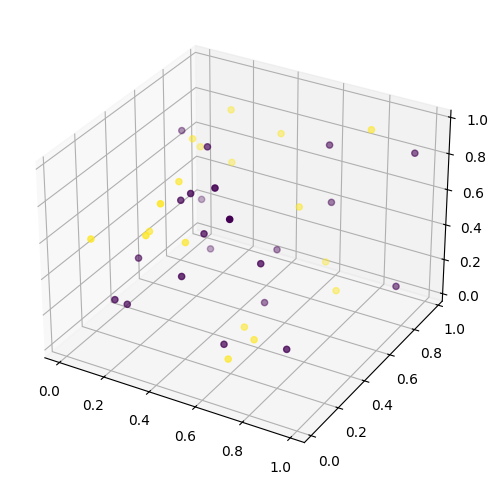

In [26]:
#Plot a graph on 3D data Feature 1, 2,3
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['Feature 1'], data['Feature 2'], data['Feature 3'], c=data['Target'])


In [27]:
#scale the whole Feture 1,2,3 Data using StandardScaler in the present data dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['Feature 1', 'Feature 2', 'Feature 3']] = scaler.fit_transform(data[['Feature 1', 'Feature 2', 'Feature 3']])

In [28]:
#Find the covariance matrix of the given data using numpy here
cov_matrix = np.cov(data[['Feature 1', 'Feature 2', 'Feature 3']].T) #.T means transpose
# cov_matrix = pd.DataFrame(cov_matrix, columns=['Feature 1', 'Feature 2', 'Feature 3'], index=['Feature 1', 'Feature 2', 'Feature 3'])
print(cov_matrix)

[[ 1.02564103  0.05669111 -0.15924274]
 [ 0.05669111  1.02564103 -0.01736083]
 [-0.15924274 -0.01736083  1.02564103]]


In [29]:
#Find the Eigenvector and EigenValue of data using numpy
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) #If working with 3D data we get 3 eigenvector & values

pc = eigenvectors[0 :2] #HERE WE WANT TO CONVERT FORM 3D TO 2D THATS WHY WE USE THE TOP 2 LARGEST EIGENVECTOR

In [30]:
#Plot the whole data to the largest EigenVector and Value respectively then plot a 2D graph [ basically take the dot product]
data_projected = np.dot(data[['Feature 1', 'Feature 2', 'Feature 3']], pc.T)
data_projected = pd.DataFrame(data_projected, columns=['Principal Component 1', 'Principal Component 2'])
data_projected['Target'] = data['Target']

data_projected.head()

,Principal Component 1,Principal Component 2,Target
0,0.774165,0.429004,1
1,-0.192578,-0.708975,0
2,-0.242976,-0.302116,1
3,-0.407303,2.062169,0
4,0.564496,-0.389576,0


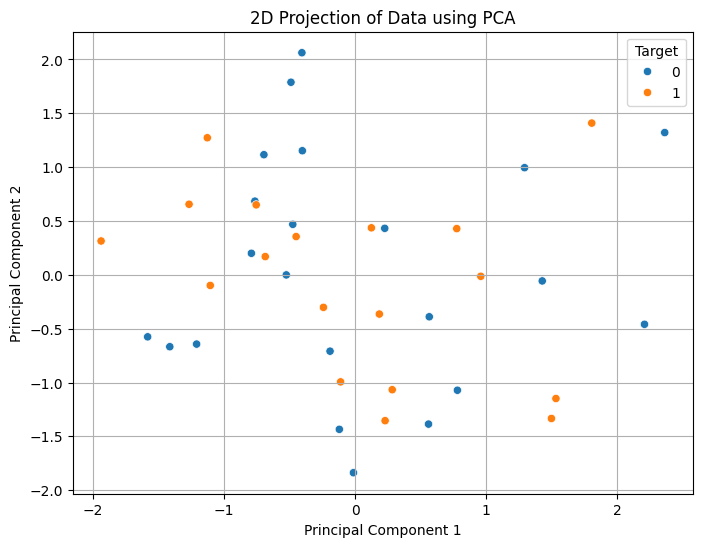

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Target', data=data_projected)
plt.title('2D Projection of Data using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


## Practical Implementation of PCA on the MNIST Dataset

In [32]:
df = pd.read_csv('/content/mnist_train.csv')
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
#Transform the whole data using StandardScaler apply SimpleImputer mean  build a pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
df = pipeline.fit_transform(df)

In [34]:
#Apply PCA for the df
from sklearn.decomposition import PCA
pca = PCA(n_components=None)
df = pca.fit_transform(df)

df = pd.DataFrame(df)
# df.head()
pca.explained_variance_ratio_

array([5.64524360e-02, 4.10932948e-02, 3.76028267e-02, 2.86774030e-02,
       2.53746183e-02, 2.22009386e-02, 1.93430705e-02, 1.73722303e-02,
       1.54626726e-02, 1.39919445e-02, 1.35051122e-02, 1.20584036e-02,
       1.11342326e-02, 1.09849349e-02, 1.03205165e-02, 9.95594969e-03,
       9.39084057e-03, 9.22190368e-03, 8.89636513e-03, 8.72014633e-03,
       8.31547270e-03, 8.09297969e-03, 7.70593113e-03, 7.46685388e-03,
       7.23025381e-03, 6.93923782e-03, 6.88731944e-03, 6.60561447e-03,
       6.35311572e-03, 6.16489834e-03, 6.01328120e-03, 5.90597130e-03,
       5.71903768e-03, 5.69108631e-03, 5.57780079e-03, 5.42955350e-03,
       5.33319730e-03, 5.20413407e-03, 5.14648040e-03, 5.07537699e-03,
       4.81671011e-03, 4.73956313e-03, 4.68549597e-03, 4.55375999e-03,
       4.53835216e-03, 4.47227642e-03, 4.40655694e-03, 4.37955572e-03,
       4.31808205e-03, 4.26394523e-03, 4.14498852e-03, 4.06867353e-03,
       4.00380707e-03, 3.97666591e-03, 3.88550153e-03, 3.83131018e-03,
      

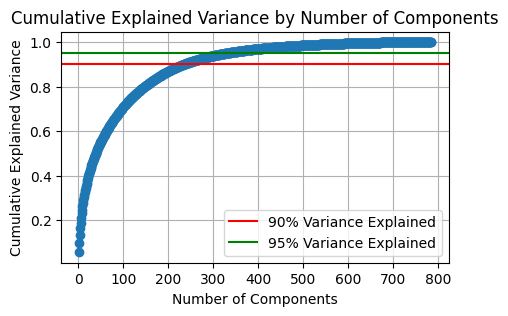

In [37]:
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(5, 3))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Optional: Add lines for common thresholds like 90% or 95%
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance Explained')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% Variance Explained')
plt.legend()

plt.show()

By looking at this plot, you can identify where the curve starts to flatten out. This 'elbow' point suggests a good trade-off between dimensionality reduction and retaining information. You can choose the number of components at which, for example, 90% or 95% of the variance is explained.